# 01 - Quickstart: netlist in, result out

DPSpice is a **topology-independent dynamic-phasor circuit simulator**. You hand
it a SPICE netlist; it parses the circuit, builds the modified-nodal-analysis
(MNA) system, picks the right solver, and runs - no manual configuration.

This notebook uses only the public Python API (`import dpspice`) and the
**bundled** example netlists, so it runs end-to-end after just:

```bash
pip install dpspice[viz]
```

Every number below is printed from a real solve at run time; nothing is
hard-coded.

In [1]:
%matplotlib inline
import dpspice
from dpspice.plotting import use_style, PALETTE
use_style()   # DPSpice house style for every figure below

print("DPSpice", dpspice.__version__, "| compute backend:", dpspice.backend())
print("bundled examples:", dpspice.list_examples())


DPSpice 1.0.3 | compute backend: python
bundled examples: ['rectifier_halfwave.raw', 'rectifier_halfwave.sp', 'rectifier_rc.sp', 'rlc.sp']


## Load a circuit and see what DPSpice decides - *before* solving

`info()` runs Tier 1 (parse + MNA) and Tier 2 (auto-estimate mode, carrier
frequency, harmonic count) and reports every decision. No solve happens yet.

In [2]:
ckt = dpspice.load(dpspice.example_text("rlc.sp"))
info = ckt.info()

print("title :", info.netlist_title)
print("nodes :", info.n_nodes, "| MNA states:", info.n_states)
print("mode  :", info.mode_selected, "->", info.reason)
print("omega :", info.omega_hz, "Hz")
print()
print("Tier-2 auto-decisions:")
for d in info.decisions:
    print(f"  {d.field:8s} = {d.value!s:18s} [{d.source}] {d.reason}")

title : Series RLC resonant circuit (Rim et al. 2025 benchmark)
nodes : 3 | MNA states: 5
mode  : idp -> linear circuit, no nonlinear devices -> IDP single-shift transient
omega : 92300.0 Hz

Tier-2 auto-decisions:
  mode     = idp                [auto] linear circuit, no nonlinear devices -> IDP single-shift transient
  omega    = 92300.0            [netlist] single SINE source at 92300 Hz


## Solve

`run()` auto-decides and simulates, returning a structured `Result`. For this
linear RLC, DPSpice selects the **instantaneous dynamic phasor (IDP)**
single-shift transient.

In [3]:
res = ckt.run()
print("solver     :", res.solver)
print("states     :", res.states)
print("solve_time : %.4f s  (machine-dependent)" % res.solve_time)
print("waveforms  :", [w.name for w in res.waveforms])

solver     : idp
states     : 5
solve_time : 0.3580 s  (machine-dependent)
waveforms  : ['V(N001)', 'V(N002)', 'V(N003)']


## Plot a node waveform

The result carries decimated per-node waveforms (`.name`, `.t`, `.v`). Here is
the output node's envelope-reconstructed time series.

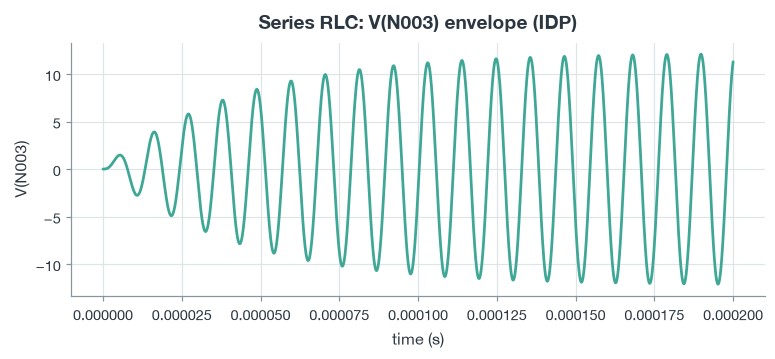

In [4]:
import matplotlib.pyplot as plt

w = res.waveforms[-1]   # the output node
fig, ax = plt.subplots()
ax.plot(w.t, w.v, color=PALETTE["teal"], lw=1.8)
ax.set_xlabel("time (s)"); ax.set_ylabel(w.name)
ax.set_title("Series RLC: %s envelope (IDP)" % w.name)
plt.tight_layout(); plt.show()


That is the whole loop: **load -> info -> run -> inspect**. The next notebooks
dig into the envelope-vs-classical speedup, cross-validation against an external
reference, the nonlinear (harmonic-balance) path, and scaling.